# 第6章 用 rocprof 找到慢在哪里

相同加法可以用不同线程分工执行。我们先测量两个正确实现，再让 rocprofv3 记录独立进程中的 kernel 启动，学习怎样筛记录、读时间和资源字段。

前置：[第5章](../chapter5/chapter5.ipynb)。对应[正文](../../../docs/part1-profiling/chapter6/index.md)。本 notebook 用整 block 的分工表达连续与跨步，不预设 wavefront 的固定宽度。


## 6.1 先运行两个向量加法

连续版让每个线程算一个元素。linecross 教学反例让线程每轮跨着取元素，但所有输出仍各写一次。它同时改变每线程工作量和 block 数；时间差不能只归因于一种硬件机制。


In [ ]:
%run ../../common/bootstrap.py

import torch
import hello_gpu as gpu
from hello_gpu import learning, profiling
%load_ext hello_gpu
cfg = gpu.settings()
env = gpu.environment()
env


In [ ]:
%%hip vector_add --entry vector_add
__global__ void vector_add(const float* a, const float* b, float* c, int n) {
    int64_t i = static_cast<int64_t>(blockIdx.x) * blockDim.x + threadIdx.x;
    if (i < n) c[i] = a[i] + b[i];
}


In [ ]:
%%hip linecross --entry linecross
__global__ void linecross(const float* a, const float* b, float* c, int n) {
    const int ITEMS = 8;
    int64_t base = static_cast<int64_t>(blockIdx.x) * blockDim.x * ITEMS;
    for (int j = 0; j < ITEMS; ++j) {
        int64_t i = base + static_cast<int64_t>(threadIdx.x) * ITEMS + j;
        if (i < n) c[i] = a[i] + b[i];
    }
}


In [ ]:
a, b = learning.inputs(cfg['n'] + 17, seed=cfg['seed'])
outputs = {name: torch.empty_like(a) for name in ('contiguous', 'linecross')}
ITEMS = 8
linecross_grid = (a.numel() + cfg['block'] * ITEMS - 1) // (cfg['block'] * ITEMS)
calls = {'contiguous': vector_add.prepare(a, b, block=cfg['block'], out=outputs['contiguous']),
         'linecross': linecross.prepare(a, b, block=cfg['block'], grid_limit=linecross_grid,
                                        out=outputs['linecross'])}
table = learning.compare(calls, reference=a+b, outputs=outputs,
                         warmup=cfg['warmup'], repeat=cfg['repeat'], bytes_moved=12*a.numel())
table


In [ ]:
learning.plot_comparison(table, baseline='contiguous')


## 6.2 把线程分工画出来

先在纸上找一个 thread 对应的下标。连续版相邻线程访问相邻元素，linecross 版相邻线程在同轮访问相隔 ITEMS 的元素。这个图用于解释地址顺序，不规定你的设备怎样合并物理事务。


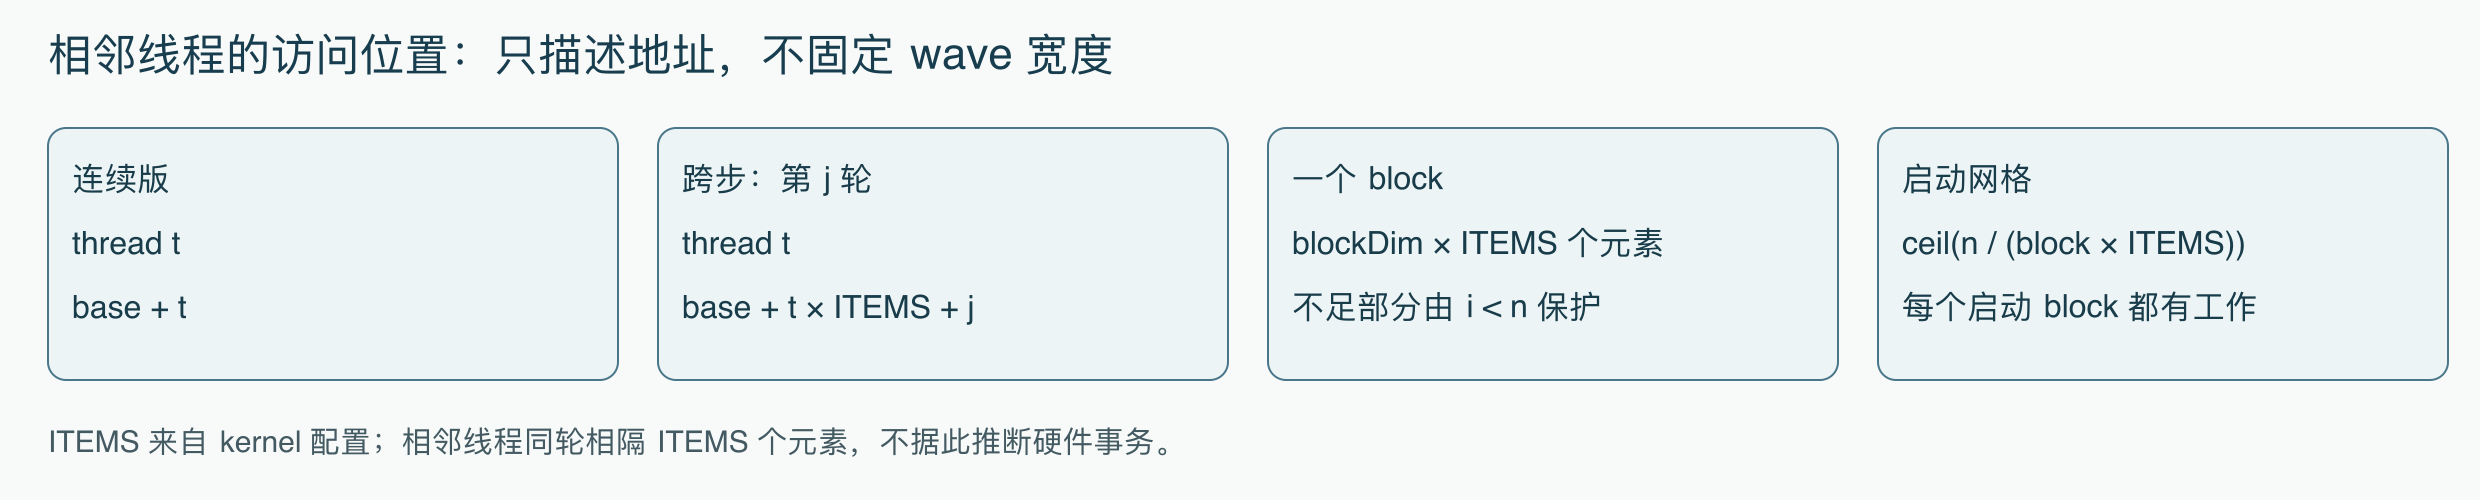

*该图对应当前 block 级索引公式，不标注固定 wavefront 宽度。*


In [ ]:
import pandas as pd
pd.DataFrame({'thread': range(8), 'contiguous': range(8),
              'linecross_round0': [i*ITEMS for i in range(8)]})


## 6.3 让 rocprofv3 记录 kernel 的执行

profiling 在另一个进程进行，读入本 notebook 当前 kernel 源码。首次编译、校验和参考算子也会产生活动，不能把整份 CSV 的行数当作目标 launch 次数。

如果你的环境没有 rocprofv3，下面显示 unavailable；可以在 `config.toml` 指定安装路径或把 profiling.enabled 改为 false，然后继续学习 CSV 的读法。


In [ ]:
profiling.capabilities()


In [ ]:
trace = profiling.kernel_trace({'vector_add': vector_add, 'linecross': linecross},
                               n=a.numel(), block=cfg['block'], launches=3, label='chapter6',
                               grid_limits={'linecross': linecross_grid})
print({k:v for k,v in trace.items() if k not in ('table','input','environment')})


## 6.4 从 CSV 中读懂一次启动

Start/End Timestamp 的单位是纳秒，差值除以 1000 得微秒。只筛本章命名的 kernel，再核对启动次数、grid、workgroup；缺失字段保留缺失，不填成零。


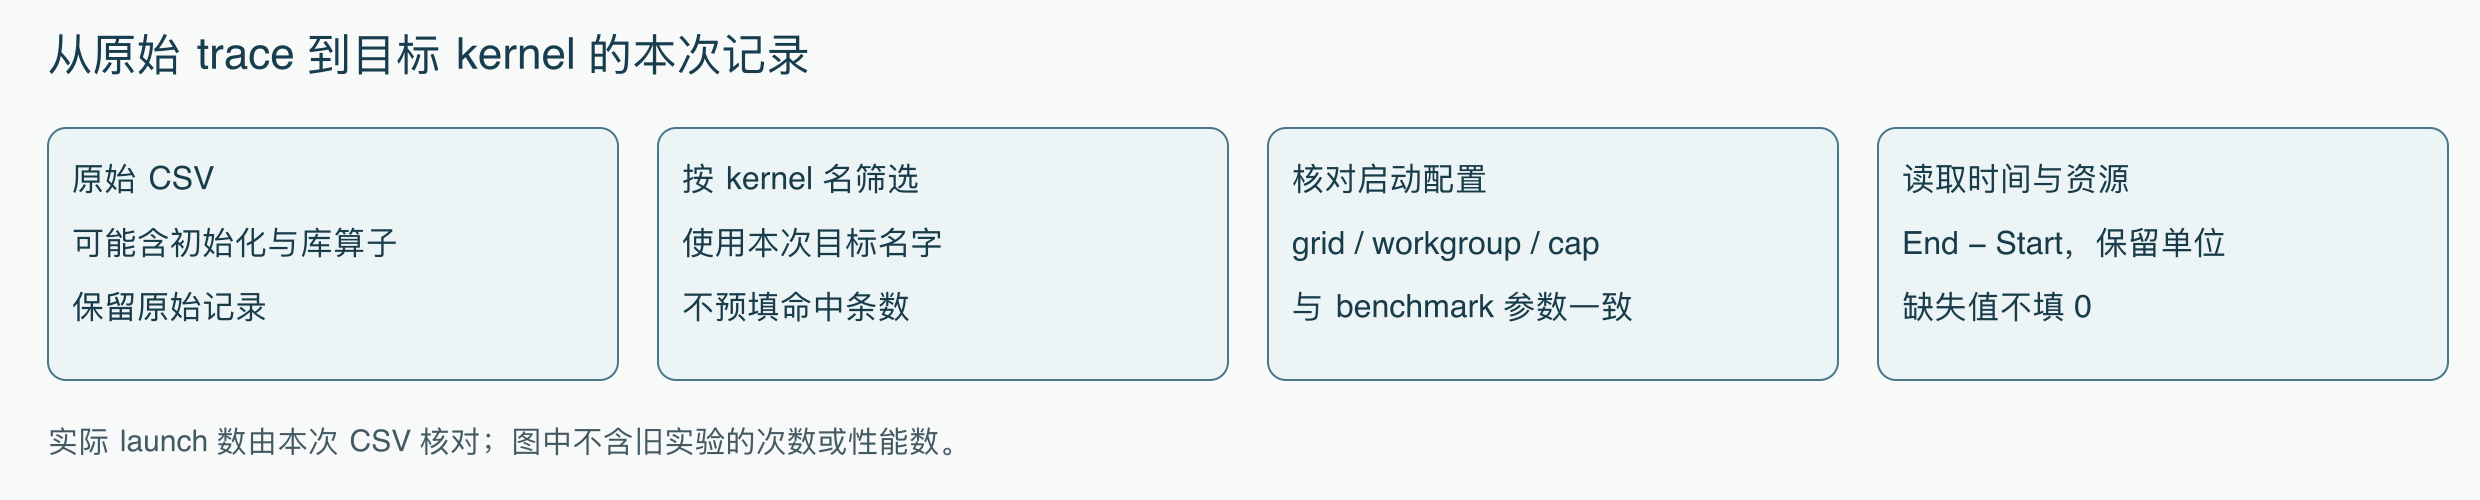

*本次 trace 的筛选顺序示意；最终字段与条数以实际采集为准。*


In [ ]:
profiling.trace_summary(trace)


## 6.5 这些证据还不能说明什么

VGPR/SGPR/LDS 字段描述每次启动的资源信息，单凭寄存器数不能计算利用率。kernel 时间与 event 区间的口径也不同。没有有效计数器或 ISA 对照时，缓存命中率、occupancy 和访存事务只能作为待检验假设。


In [ ]:
print('当前可读字段：', list(trace.get('table', pd.DataFrame()).columns))


## 6.6 用 stride 扫描提出下一步实验

固定 block 和输入，真正改变 kernel 中的 ITEMS：它同时改变每线程循环次数、同轮跨步距离与有工作 block 数。每个版本按 ceil(n / (block × ITEMS)) 限制 grid，避免大量空跑 block。每次都重新编译、对答案并计时，不借用正文历史数据。


In [ ]:
scan_calls, scan_outputs, scan_kernels, scan_launches = {}, {}, [], {}
for items in (4, 8, 16):
    source = linecross.source.replace('const int ITEMS = 8;', f'const int ITEMS = {items};')
    kernel = gpu.compile_kernel(f'linecross_items_{items}', source, entry='linecross')
    cap = (a.numel() + cfg['block'] * items - 1) // (cfg['block'] * items)
    name = f'linecross ITEMS={items}'
    scan_outputs[name] = torch.empty_like(a)
    scan_calls[name] = kernel.prepare(a, b, block=cfg['block'], grid_limit=cap,
                                      out=scan_outputs[name])
    scan_kernels.append(kernel)
    scan_launches[name] = {'ITEMS': items, 'block': cfg['block'], 'grid_limit': cap}
scan_table = learning.compare(scan_calls, reference=a+b, outputs=scan_outputs,
                               warmup=cfg['warmup'], repeat=cfg['repeat'],
                               bytes_moved=12*a.numel())
scan_table


## 6.7 练习

在扫描中增加 ITEMS=2，重新编译、检查全部答案、测量，再用对应 grid cap 采 trace。分别写出“源码改变了什么”“时间观察到什么”和“还没证明什么”。比较时固定输入和计时方法。


In [ ]:
record = learning.save_table('part1-profiling/chapter6',table,
                             config={**cfg,'n':a.numel(),'trace_status':trace['status']},
                             kernels=[vector_add,linecross],
                             launches={'contiguous': {'block':cfg['block']},
                                       'linecross': {'ITEMS':ITEMS,'block':cfg['block'],'grid_limit':linecross_grid}})
scan_record = learning.save_table('part1-profiling/chapter6-items',scan_table,
                                  config={**cfg,'n':a.numel()},kernels=scan_kernels,launches=scan_launches)
record, scan_record


## 本章小结

我们用独立的 profiler 采集路径解释 kernel dispatch，按名称筛选真实记录，保留字段边界。下一章把算法工作量与本机测量一起放进 Roofline。

## 延伸阅读

- [第7章 notebook](../chapter7/chapter7.ipynb)
- [rocprofv3 官方指南](https://rocm.docs.amd.com/projects/rocprofiler-sdk/en/latest/how-to/using-rocprofv3.html)
